In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import os
import shutil
from tqdm import tqdm

In [3]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research/dataset"
ZIP_PATH = f"{PROJECT_DIR}/dataset/WilderPerson.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/WilderPerson.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [4]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/WilderPerson.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [5]:
import os
import shutil
from tqdm import tqdm

ORIGINAL_DATASET = "/content/final-year-research/dataset/dataset"
SAM_ANON_DATASET = "/content/final-year-research/dataset/wilderperson_sam_fullbody_anonymized"
splits = ["train", "valid"]

if os.path.exists(SAM_ANON_DATASET):
    shutil.rmtree(SAM_ANON_DATASET)

In [6]:
for split in splits:
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")
    dst_labels = os.path.join(SAM_ANON_DATASET, split, "labels")
    os.makedirs(dst_labels, exist_ok=True)

    for file in os.listdir(src_labels):
        shutil.copy(
            os.path.join(src_labels, file),
            os.path.join(dst_labels, file)
        )

print("Labels copied successfully")

Labels copied successfully


In [7]:
!ls /content/final-year-research/dataset/

dataset  wilderperson_sam_fullbody_anonymized  WilderPerson.zip


In [7]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python pycocotools matplotlib

  Preparing metadata (setup.py) ... done


In [8]:
!wget -O sam_vit_b_01ec64.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-04-17 09:21:12--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.39, 13.249.182.33, 13.249.182.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   276MB/s    in 1.3s    

2026-04-17 09:21:14 (276 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [10]:
import torch
import cv2
import numpy as np
from segment_anything import sam_model_registry, SamPredictor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_TYPE = "vit_b"
CHECKPOINT_PATH = "/content/sam_vit_b_01ec64.pth"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=DEVICE)

predictor = SamPredictor(sam)

print("SAM loaded on:", DEVICE)

SAM loaded on: cuda


In [11]:
def yolo_to_xyxy(label_line, img_w, img_h):
    cls, x, y, w, h = map(float, label_line.strip().split())

    x *= img_w
    y *= img_h
    w *= img_w
    h *= img_h

    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w - 1, x2)
    y2 = min(img_h - 1, y2)

    return int(cls), x1, y1, x2, y2

In [12]:
def sam_segment_person(image_bgr, box_xyxy):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    input_box = np.array(box_xyxy, dtype=np.float32)

    masks, scores, logits = predictor.predict(
        box=input_box,
        multimask_output=True
    )

    best_idx = np.argmax(scores)
    best_mask = masks[best_idx]  # boolean mask, shape HxW

    return best_mask, scores[best_idx]

In [13]:
BLUR_KERNEL = (21, 21)
BLUR_SIGMA = 5

for split in splits:
    src_images = os.path.join(ORIGINAL_DATASET, split, "images")
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")
    dst_images = os.path.join(SAM_ANON_DATASET, split, "images_blur")

    os.makedirs(dst_images, exist_ok=True)

    for img_name in tqdm(os.listdir(src_images), desc=f"Blur Processing {split}"):
        img_path = os.path.join(src_images, img_name)
        label_path = os.path.join(src_labels, img_name.rsplit(".", 1)[0] + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_h, img_w = img.shape[:2]
        out_img = img.copy()

        if not os.path.exists(label_path):
            cv2.imwrite(os.path.join(dst_images, img_name), out_img)
            continue

        with open(label_path, "r") as f:
            labels = f.readlines()

        blurred_full = cv2.GaussianBlur(out_img, BLUR_KERNEL, BLUR_SIGMA)

        for line in labels:
            cls, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

            if cls != 0:
                continue

            if x2 <= x1 or y2 <= y1:
                continue

            try:
                mask, score = sam_segment_person(out_img, [x1, y1, x2, y2])
                out_img[mask] = blurred_full[mask]
            except Exception as e:
                print(f"Error on {img_name}: {e}")

        cv2.imwrite(os.path.join(dst_images, img_name), out_img)

print("SAM full-body blurred dataset created successfully")

Blur Processing train:   0%|          | 11/10098 [01:38<25:07:38,  8.97s/it]


KeyboardInterrupt: 

In [ ]:
sample_images = sorted(os.listdir(src_images))[:50]

Testing on one image

In [ ]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research/dataset"
ZIP_PATH = f"{PROJECT_DIR}/dataset/WilderPerson.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/WilderPerson.zip")
print("Copied zip to Colab VM")

In [ ]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/WilderPerson.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Selected image: 001334_jpg.rf.f2928d3f210f40a718ddc2c645f191df.jpg


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

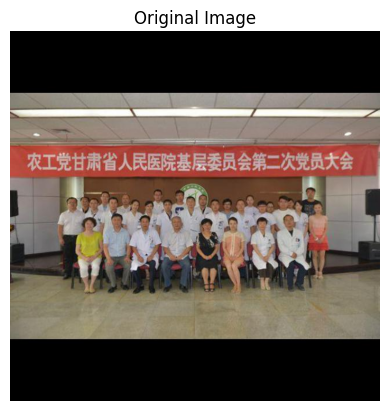

In [24]:
import os
import random
import cv2
import matplotlib.pyplot as plt

IMAGE_DIR = "/content/final-year-research/dataset/dataset/train/images"
LABEL_DIR = "/content/final-year-research/dataset/dataset/train/labels"

img_name = random.choice(os.listdir(IMAGE_DIR))

img_path = os.path.join(IMAGE_DIR, img_name)
label_path = os.path.join(LABEL_DIR, img_name.replace(".jpg", ".txt"))

print("Selected image:", img_name)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

In [23]:
import torch
from segment_anything import sam_model_registry, SamPredictor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="/content/sam_vit_b_01ec64.pth")
sam.to(device=DEVICE)

predictor = SamPredictor(sam)

In [25]:
def yolo_to_xyxy(label_line, img_w, img_h):
    cls, x, y, w, h = map(float, label_line.strip().split())

    x *= img_w
    y *= img_h
    w *= img_w
    h *= img_h

    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    return int(cls), x1, y1, x2, y2

In [13]:
def expand_box(x1, y1, x2, y2, img_w, img_h):
    bw = x2 - x1
    bh = y2 - y1

    # expand downward (body)
    new_x1 = max(0, x1 - int(bw * 0.5))
    new_x2 = min(img_w - 1, x2 + int(bw * 0.5))

    new_y1 = max(0, y1 - int(bh * 0.3))   # little upward
    new_y2 = min(img_h - 1, y2 + int(bh * 4.0))  # extend down for body

    return new_x1, new_y1, new_x2, new_y2

In [26]:
import numpy as np

img_h, img_w = img.shape[:2]

predictor.set_image(img_rgb)

with open(label_path, "r") as f:
    labels = f.readlines()

boxes = []

for line in labels:
    cls, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

    # keep only pedestrian class
    if cls == 0:
        boxes.append([x1, y1, x2, y2])

boxes = np.array(boxes)

print("Number of pedestrian boxes:", len(boxes))
print(boxes)

Number of pedestrian boxes: 33
[[198 285 224 307]
 [475 288 491 307]
 [441 293 457 312]
 [490 291 506 311]
 [426 292 444 312]
 [121 285 138 305]
 [462 284 481 306]
 [284 274 301 295]
 [346 289 363 310]
 [366 289 383 309]
 [156 275 173 296]
 [232 292 249 313]
 [303 285 320 307]
 [472 315 493 340]
 [407 281 423 300]
 [376 321 394 343]
 [169 286 186 308]
 [389 290 406 310]
 [324 281 341 302]
 [523 293 540 314]
 [264 289 281 310]
 [425 320 444 344]
 [136 287 154 309]
 [ 97 286 116 308]
 [192 279 208 300]
 [247 272 264 294]
 [223 317 242 342]
 [207 290 224 310]
 [278 318 298 343]
 [511 269 528 289]
 [126 321 147 344]
 [329 323 349 346]
 [175 314 195 337]]


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

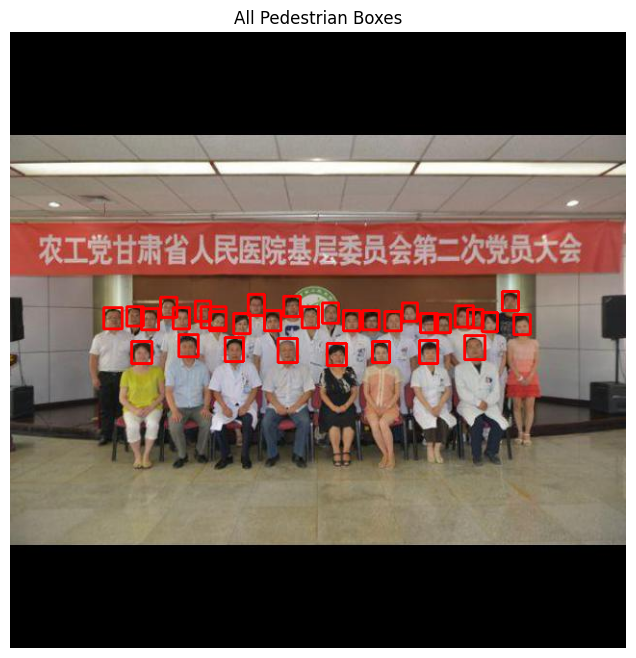

In [27]:
import cv2
import matplotlib.pyplot as plt

img_box = img_rgb.copy()

for (x1, y1, x2, y2) in boxes:
    cv2.rectangle(img_box, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(img_box)
plt.title("All Pedestrian Boxes")
plt.axis("off")

In [28]:
import numpy as np

img_h, img_w = img.shape[:2]

predictor.set_image(img_rgb)

with open(label_path, "r") as f:
    labels = f.readlines()


boxes = []

for line in labels:
    cls, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

    if cls == 0:
        boxes.append([x1, y1, x2, y2])

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

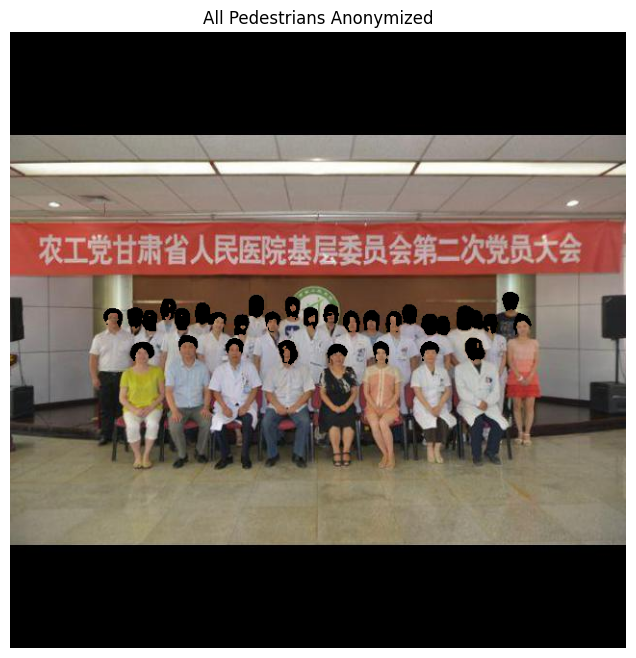

In [29]:
output_img = img_rgb.copy()

for box in boxes:
    masks, scores, _ = predictor.predict(
        box=np.array(box),
        multimask_output=True
    )

    # choose largest mask
    areas = [mask.sum() for mask in masks]
    best_idx = np.argmax(areas)
    best_mask = masks[best_idx]

    # black anonymization
    output_img[best_mask] = [0, 0, 0]

plt.figure(figsize=(10, 8))
plt.imshow(output_img)
plt.title("All Pedestrians Anonymized")
plt.axis("off")

In [20]:
masks, scores, _ = predictor.predict(
    box=box,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]

AttributeError: 'list' object has no attribute 'reshape'

In [21]:
blurred = cv2.GaussianBlur(img_rgb, (21, 21), 5)

masked_img = img_rgb.copy()
masked_img[best_mask] = blurred[best_mask]

NameError: name 'masked_img' is not defined

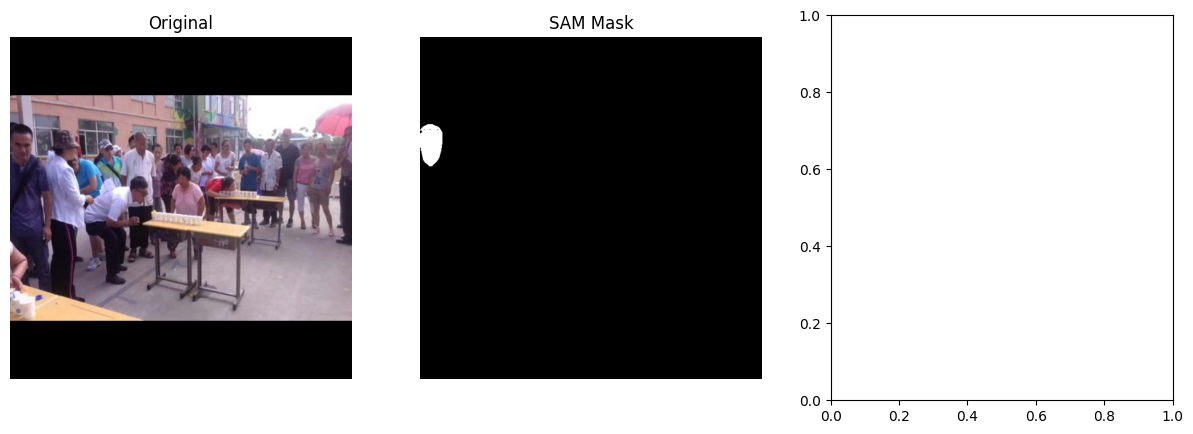

In [19]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(best_mask, cmap="gray")
plt.title("SAM Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(masked_img)
plt.title("Anonymized Output")
plt.axis("off")

In [22]:
import matplotlib.pyplot as plt
import cv2

img_box = img_rgb.copy()
x1, y1, x2, y2 = box.astype(int)

cv2.rectangle(img_box, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(6,6))
plt.imshow(img_box)
plt.title("YOLO Prompt Box")
plt.axis("off")

AttributeError: 'list' object has no attribute 'astype'

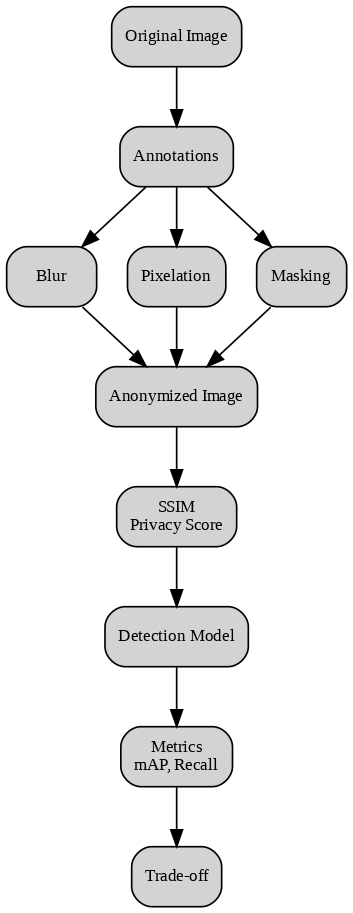

In [2]:
!apt-get -qq install graphviz
!pip -q install graphviz

from graphviz import Digraph
from IPython.display import Image, display

dot = Digraph(format='png')

# Reduce overall size
dot.attr(rankdir='TB')
dot.attr(size='6,8')      # smaller canvas
dot.attr(dpi='120')       # lower resolution
dot.attr('node', shape='box', style='rounded,filled', fontsize='10')

# Nodes
dot.node('A', 'Original Image')
dot.node('B', 'Annotations')

dot.node('C1', 'Blur')
dot.node('C2', 'Pixelation')
dot.node('C3', 'Masking')

dot.node('D', 'Anonymized Image')
dot.node('E', 'SSIM\nPrivacy Score')
dot.node('F', 'Detection Model')
dot.node('G', 'Metrics\nmAP, Recall')
dot.node('H', 'Trade-off')

# Edges
dot.edge('A', 'B')
dot.edge('B', 'C1')
dot.edge('B', 'C2')
dot.edge('B', 'C3')

dot.edge('C1', 'D')
dot.edge('C2', 'D')
dot.edge('C3', 'D')

dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'H')

# Save and display properly scaled
file_path = dot.render('small_diagram')

display(Image(filename=file_path))